In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.metrics import accuracy_score
import os

c:\Weekly_Hw_GR1\venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [2]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ex7', 'data', 'news_1135')
data_train = load_files(data_dir, encoding = 'utf-8')

In [3]:
data_train.filenames.shape

(1135,)

In [4]:
data_train.target_names

['Giải trí',
 'Khoa học - Công nghệ',
 'Kinh tế',
 'Pháp luật',
 'Sức khỏe',
 'Thể thao',
 'Thời sự',
 'Tin kh†c',
 'Độc giả',
 'Đời sống - Xã hội']

In [5]:
data_train.data[:10]

['Dân_trí Sở GD & ĐT tỉnh Gia_Lai vừa ra văn_bản số 2258 / SGDĐT - VP , về việc chấn_chỉnh việc tiếp_thị sách và các vật_dụng khác trong các cơ_sở giáo_dục . Văn_bản chỉ_đạo , tuyệt_đối không cho phép các cá_nhân , tập_thể đến trường tiếp_thị , quảng_cáo mua_bán sách , dụng_cụ học_tập … cho giáo_viên và học_sinh trong nhà_trường . Các tổ_chức , cá_nhân trong ngành giáo_dục tuyệt_đối không được thực_hiện hoặc tham_gia giới_thiệu , quảng_bá , vận_động mua , phát_hành sách tham_khảo tới học_sinh hoặc phụ_huynh dưới hình_thức nào . Nhà_trường tuyệt_đối không được lưu_hành , sử_dụng sách có nội_dung không lành_mạnh , không phù_hợp với nội_dung chương_trình phổ_thông . Trường_hợp phát_hiện sách có sai_sót , các đơn_vị cần báo_cáo với cấp trên để có hướng xử_lý . Các sơ sở giáo_dục đề_cao cảnh_giác đối_với trường_hợp mạo_danh cán_bộ , chuyên_viên sở trong ngành đi giới_thiệu sách , đồ_dùng học_sinh ; công_khai phổ_biến các quy_định trên đến cán_bộ , giáo_viên , học_sinh để cùng phòng tránh và

In [6]:
stop_word_dir = os.path.join(base_dir, 'Ex7', 'data', 'vietnamese-stopwords.txt')
with open(stop_word_dir, 'r', encoding = 'utf-8') as f:
    stopwords = f.readlines()
stopwords

['a lô\n',
 'a ha\n',
 'ai\n',
 'ai ai\n',
 'ai nấy\n',
 'ai đó\n',
 'alô\n',
 'amen\n',
 'anh\n',
 'anh ấy\n',
 'ba\n',
 'ba ba\n',
 'ba bản\n',
 'ba cùng\n',
 'ba họ\n',
 'ba ngày\n',
 'ba ngôi\n',
 'ba tăng\n',
 'bao giờ\n',
 'bao lâu\n',
 'bao nhiêu\n',
 'bao nả\n',
 'bay biến\n',
 'biết\n',
 'biết bao\n',
 'biết bao nhiêu\n',
 'biết chắc\n',
 'biết chừng nào\n',
 'biết mình\n',
 'biết mấy\n',
 'biết thế\n',
 'biết trước\n',
 'biết việc\n',
 'biết đâu\n',
 'biết đâu chừng\n',
 'biết đâu đấy\n',
 'biết được\n',
 'buổi\n',
 'buổi làm\n',
 'buổi mới\n',
 'buổi ngày\n',
 'buổi sớm\n',
 'bà\n',
 'bà ấy\n',
 'bài\n',
 'bài bác\n',
 'bài bỏ\n',
 'bài cái\n',
 'bác\n',
 'bán\n',
 'bán cấp\n',
 'bán dạ\n',
 'bán thế\n',
 'bây bẩy\n',
 'bây chừ\n',
 'bây giờ\n',
 'bây nhiêu\n',
 'bèn\n',
 'béng\n',
 'bên\n',
 'bên bị\n',
 'bên có\n',
 'bên cạnh\n',
 'bông\n',
 'bước\n',
 'bước khỏi\n',
 'bước tới\n',
 'bước đi\n',
 'bạn\n',
 'bản\n',
 'bản bộ\n',
 'bản riêng\n',
 'bản thân\n',
 'bản ý\n',
 '

In [7]:
stopwords = [i.strip().replace(" ","_") for i in stopwords]
stopwords

['a_lô',
 'a_ha',
 'ai',
 'ai_ai',
 'ai_nấy',
 'ai_đó',
 'alô',
 'amen',
 'anh',
 'anh_ấy',
 'ba',
 'ba_ba',
 'ba_bản',
 'ba_cùng',
 'ba_họ',
 'ba_ngày',
 'ba_ngôi',
 'ba_tăng',
 'bao_giờ',
 'bao_lâu',
 'bao_nhiêu',
 'bao_nả',
 'bay_biến',
 'biết',
 'biết_bao',
 'biết_bao_nhiêu',
 'biết_chắc',
 'biết_chừng_nào',
 'biết_mình',
 'biết_mấy',
 'biết_thế',
 'biết_trước',
 'biết_việc',
 'biết_đâu',
 'biết_đâu_chừng',
 'biết_đâu_đấy',
 'biết_được',
 'buổi',
 'buổi_làm',
 'buổi_mới',
 'buổi_ngày',
 'buổi_sớm',
 'bà',
 'bà_ấy',
 'bài',
 'bài_bác',
 'bài_bỏ',
 'bài_cái',
 'bác',
 'bán',
 'bán_cấp',
 'bán_dạ',
 'bán_thế',
 'bây_bẩy',
 'bây_chừ',
 'bây_giờ',
 'bây_nhiêu',
 'bèn',
 'béng',
 'bên',
 'bên_bị',
 'bên_có',
 'bên_cạnh',
 'bông',
 'bước',
 'bước_khỏi',
 'bước_tới',
 'bước_đi',
 'bạn',
 'bản',
 'bản_bộ',
 'bản_riêng',
 'bản_thân',
 'bản_ý',
 'bất_chợt',
 'bất_cứ',
 'bất_giác',
 'bất_kì',
 'bất_kể',
 'bất_kỳ',
 'bất_luận',
 'bất_ngờ',
 'bất_nhược',
 'bất_quá',
 'bất_quá_chỉ',
 'bất_thình_l

In [8]:
module_count_vector = CountVectorizer(stop_words = stopwords)
model_rf_preprocess = Pipeline([('vect', module_count_vector), ('tfidf', TfidfTransformer())])

In [9]:
# vector hóa theo kiểu bow, có tất cả 1135 sample và từ điển 24389 từ
module_count_vector.fit_transform(data_train.data).toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1135, 24389))

In [10]:
# vector hóa theo tfidf
model_rf_preprocess.fit_transform(data_train.data).toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00879757, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(1135, 24389))

In [11]:
# có thể sử dụng trực tiếp TfidfTransformer mà không cần dùng đến pipeline
model_tfidf = TfidfVectorizer(stop_words = stopwords)

Chú ý TfidfTransformer yêu cầu đầu vào là ma trận tần suất từ trong khi TfidfVectorizer tích hợp luôn cả đôi việc

In [12]:
model_tfidf.fit_transform(data_train.data).toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.00879757, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(1135, 24389))

In [13]:
# hiển thị 10 từ trong văn bản đầu tiên có giá trị tfidf cao nhất
first_sample = data_train.data[0]
print(f"first sample: {first_sample}")
vector1 = model_tfidf.transform([first_sample]).toarray()[0]
index_desc = np.argsort(vector1)[::-1]
index_desc = index_desc[:10]
# tạo 1 dict với khóa là id values là token cho dễ truy cập
index_token_dict = {id:token for token, id in model_tfidf.vocabulary_.items()}
for i in index_desc:
    print(f"{index_token_dict[i]}, tfidf: {vector1[i]}")

first sample: Dân_trí Sở GD & ĐT tỉnh Gia_Lai vừa ra văn_bản số 2258 / SGDĐT - VP , về việc chấn_chỉnh việc tiếp_thị sách và các vật_dụng khác trong các cơ_sở giáo_dục . Văn_bản chỉ_đạo , tuyệt_đối không cho phép các cá_nhân , tập_thể đến trường tiếp_thị , quảng_cáo mua_bán sách , dụng_cụ học_tập … cho giáo_viên và học_sinh trong nhà_trường . Các tổ_chức , cá_nhân trong ngành giáo_dục tuyệt_đối không được thực_hiện hoặc tham_gia giới_thiệu , quảng_bá , vận_động mua , phát_hành sách tham_khảo tới học_sinh hoặc phụ_huynh dưới hình_thức nào . Nhà_trường tuyệt_đối không được lưu_hành , sử_dụng sách có nội_dung không lành_mạnh , không phù_hợp với nội_dung chương_trình phổ_thông . Trường_hợp phát_hiện sách có sai_sót , các đơn_vị cần báo_cáo với cấp trên để có hướng xử_lý . Các sơ sở giáo_dục đề_cao cảnh_giác đối_với trường_hợp mạo_danh cán_bộ , chuyên_viên sở trong ngành đi giới_thiệu sách , đồ_dùng học_sinh ; công_khai phổ_biến các quy_định trên đến cán_bộ , giáo_viên , học_sinh để cùng ph

In [14]:
data_preprocessed = model_tfidf.fit_transform(data_train.data)

In [15]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size = 0.2, random_state = 36)
X_train.shape, y_train.shape

((908, 24389), (908,))

Pipeline sẽ là chuyển các text về vector rồi sử dụng svm để phân loại với đầu vào là ma trận của các vector và nhãn của các text

In [16]:
# training svm linear
model_svm_linear = svm.SVC(kernel = 'linear', C = 1)
model_svm_linear.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
y_pred_svm_linear_test = model_svm_linear.predict(X_test)
y_pred_svm_linear_train = model_svm_linear.predict(X_train)
print(f"accuracy_score of train: {accuracy_score(y_train, y_pred_svm_linear_train)}")
print(f"accuracy_score of test: {accuracy_score(y_test, y_pred_svm_linear_test)}")

accuracy_score of train: 0.9955947136563876
accuracy_score of test: 0.8634361233480177


In [18]:
model_svm_rbf = svm.SVC(kernel = 'rbf', C=1)
model_svm_rbf.fit(X_train, y_train)
y_pred_svm_rbf_test = model_svm_rbf.predict(X_test)
y_pred_svm_rbf_train = model_svm_rbf.predict(X_train)
print(f"accuracy_score of train: {accuracy_score(y_train, y_pred_svm_rbf_train)}")
print(f"accuracy_score of test: {accuracy_score(y_test, y_pred_svm_rbf_test)}")


accuracy_score of train: 0.9966960352422908
accuracy_score of test: 0.7709251101321586


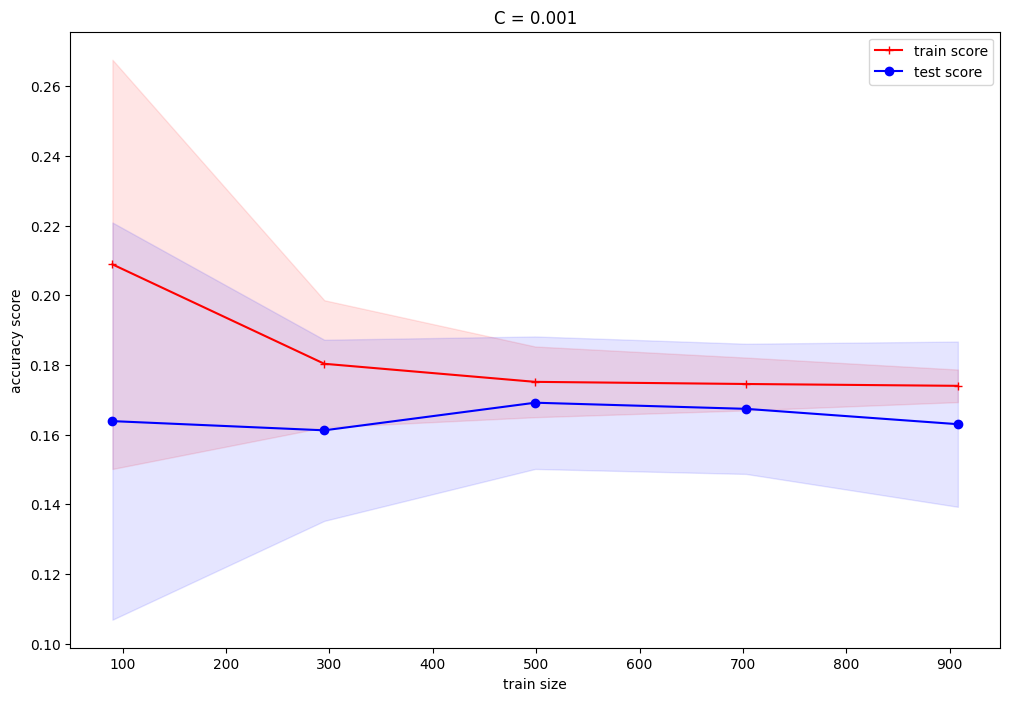

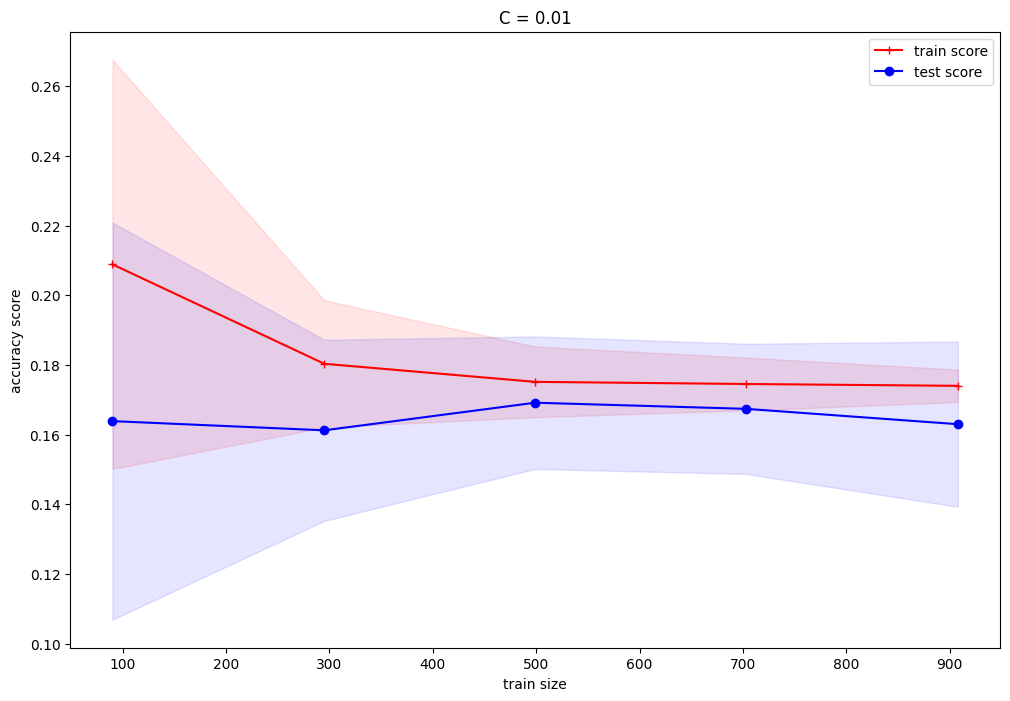

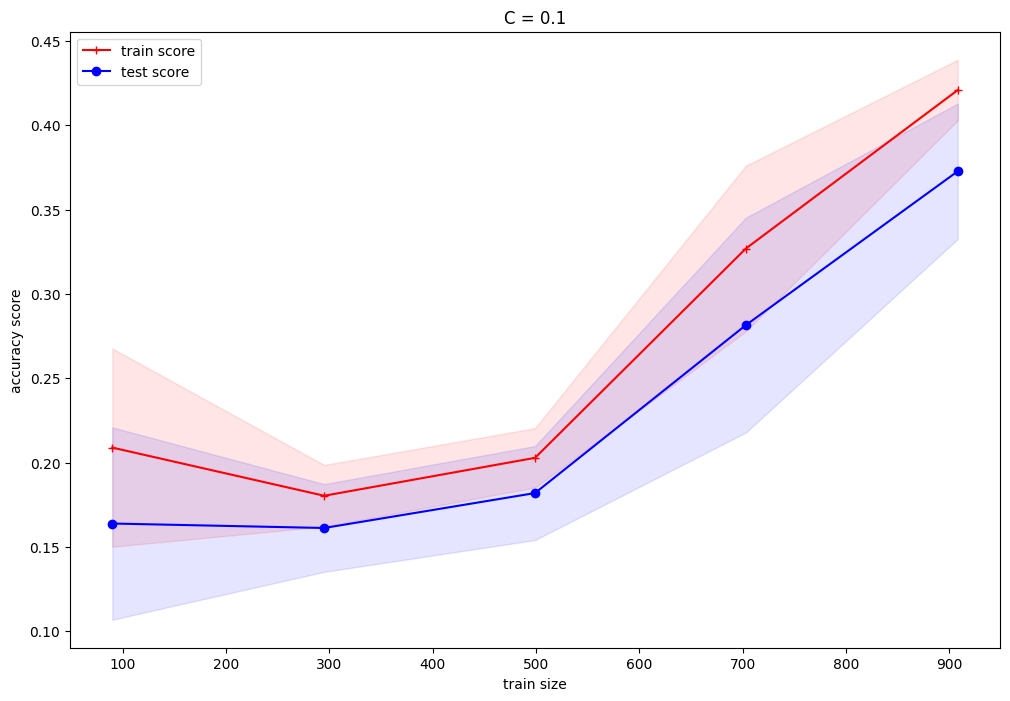

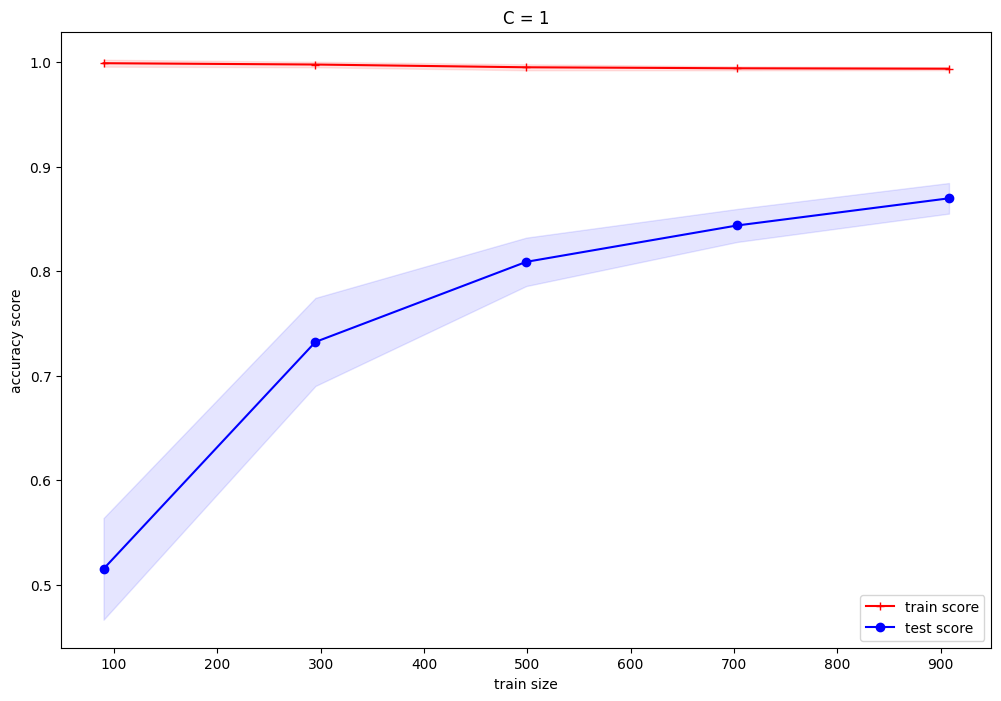

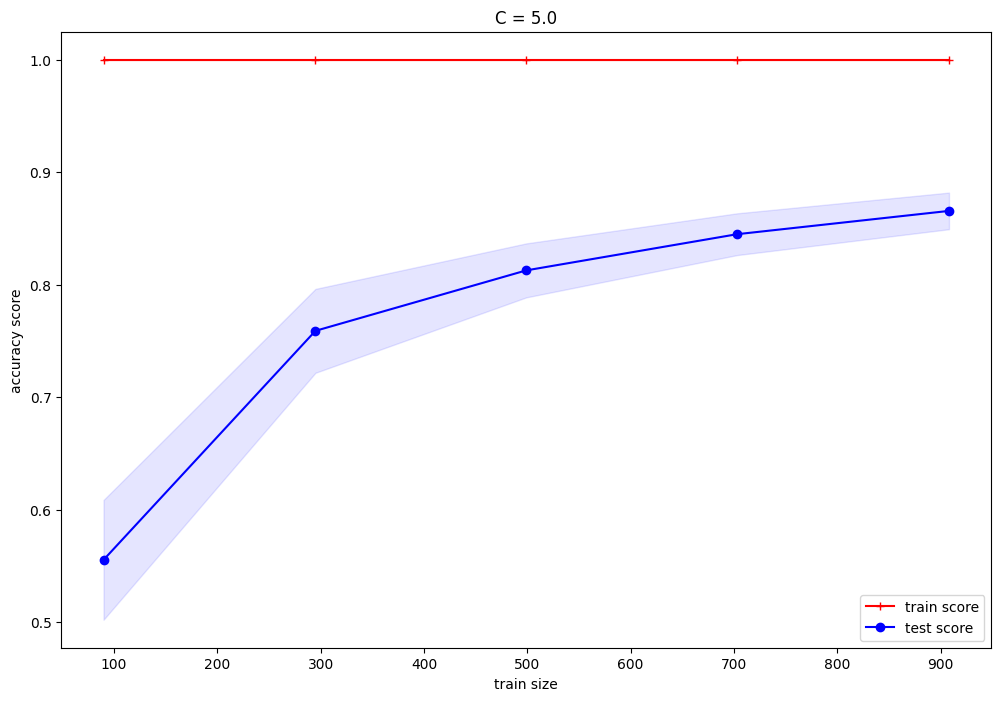

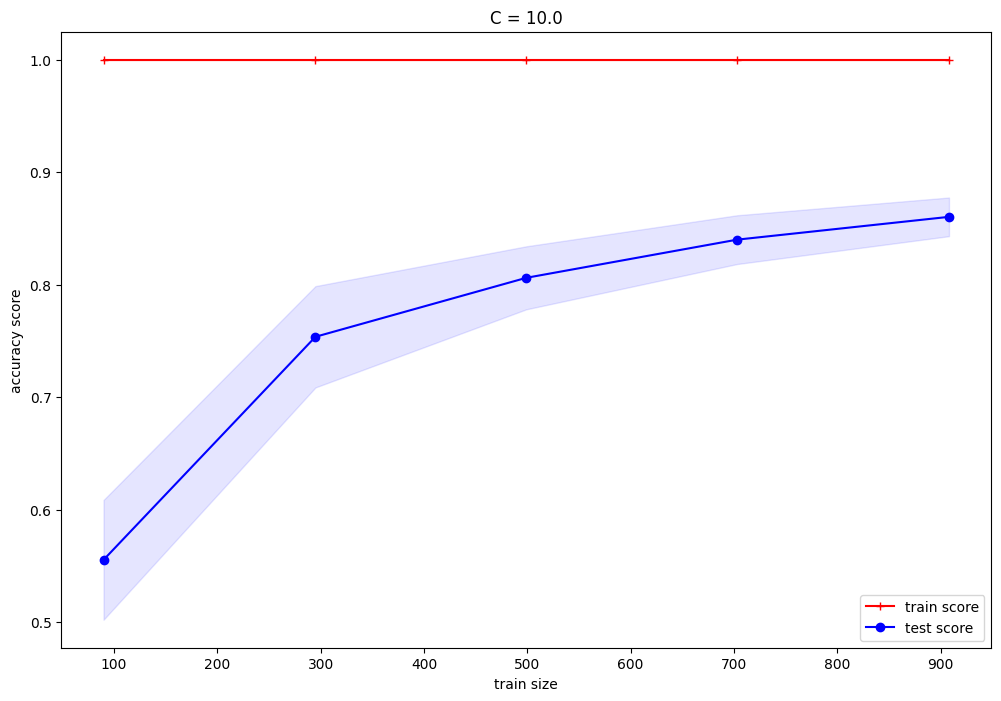

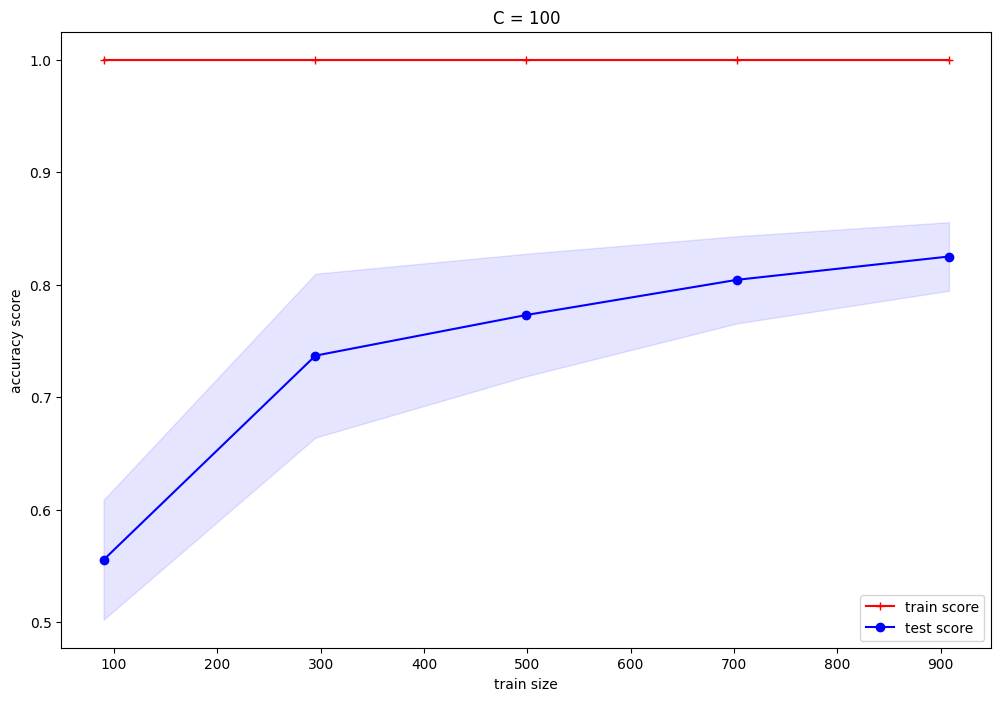

In [24]:
# learning curver của svm linear với c thay đổi sử dụng accuracy score
cv = ShuffleSplit(n_splits = 10, test_size = 0.2, random_state = 36)
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]

for i in list_C:
    train_sizes, train_scores, test_scores = learning_curve(estimator = svm.SVC(kernel = 'linear', C = i), X = data_preprocessed, y = data_train.target, cv = cv, n_jobs = -1, train_sizes = np.linspace(0.1,1.0,5), scoring = 'accuracy')
    #mối test size trải qua n split nên train_scores và test_scores là mảng 2d có chiều là len(train_sizes)*n_split
    train_scores_mean = np.mean(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)
    plt.figure(figsize = (12,8))
    plt.title(f"C = {i}")
    plt.xlabel("train size")
    plt.ylabel("accuracy score")
    plt.plot(train_sizes, train_scores_mean, marker = '+', color = 'r', label = 'train score')
    plt.plot(train_sizes, test_scores_mean, marker = 'o', color = 'b', label = 'test score')
    plt.fill_between(train_sizes, train_scores_mean + train_scores_std, train_scores_mean - train_scores_std, alpha = 0.1, color = 'r')
    plt.fill_between(train_sizes, test_scores_mean + test_scores_std, test_scores_mean - test_scores_std, alpha = 0.1, color = 'b')
    plt.legend(loc = 'best')
    plt.show()


Có thể thấy, vơi C bé thì mô hình cho phép các tham số slack lớn điều này có nghĩa là cho phép nhiều sai lầm nên độ chính xác rất thấp. Nếu C càng lớn thì càng phạt nặng các slack, nếu C tiến tới vô cùng thì sẽ thành hard margin, nếu C càng lớn thì mô hình sẽ sợ sai làm và sẽ cố fit nhiều nhất có thể điều này có thể dẫn đến overfit, có thể thấy giá trị tốt nhất của C là 1

In [28]:
# grid search chọn tổ hợp tham số phù hợp
params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
'gamma': [0.0001, 0.001, 0.01, 0.1],
'kernel':['linear','rbf', 'poly'] }
classifier = GridSearchCV(estimator = svm.SVC(), cv= cv, param_grid = params_grid, n_jobs = -1, scoring = 'accuracy')
classifier.fit(X_train, y_train)
print(classifier.best_estimator_)

SVC(C=100, gamma=0.01)


Tham số gamma không có trong các hàm kernel tuyến tính, trong hàm kernel gaussian nếu gamma càng lớn thì giá trị của kernal càng tiến về 0 điều đó đồng nghĩa với việc model chỉ xem xét các điểm có khoảng cách không quá xa nhau vì nếu quá xa nhau thì kernel sẽ bằng 0. Đối với hàm kernel poly thì gamma nằm ngay bên dưới dấu dương, nếu gamma càng lớn thì kernel của 2 điểm xa nhau càng lớn( ngược lại với rbf ), tuy nhiên thì chúng đều giống nhau nếu gamma càng lớn thì model càng ngặt hơn dễ overfit, nếu bé thì dễ underfit

In [37]:
model_svm_final = svm.SVC(C=100, gamma = 0.01)
model_svm_final.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [50]:
y_pred_final_svm = model_svm_final.predict(X_test)
accuracy_score(y_test, y_pred_final_svm)

0.8634361233480177

In [69]:
# test thử input đầu vào text bất kì
input_text = "công nghệ lõi giúp con người có thể trở nên trẻ hơn"
input_text_normalize = ViTokenizer.tokenize(input_text)
input_vector = model_tfidf.transform([input_text_normalize]).toarray()
id_pred = model_svm_final.predict(input_vector)
print(data_train.target_names[id_pred[0]])


Khoa học - Công nghệ


# Phân loại số viết tay

In [71]:
from sklearn import datasets
digits = datasets.load_digits()

In [73]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [76]:
digits.images[:4]

array([[[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
        [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
        [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
        [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
        [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
        [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
        [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
        [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
        [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
        [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
        [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
        [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
        [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
        [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
        [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]],

       [[ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.],
        [ 0.,  0.,  3., 16., 15., 14.,  0.,  0.],
        [ 0.,  0.,  8., 13.,  8., 16.,  0.,  0.],
        [ 0.,  0.,  1.,  6., 15., 11.,  0.,  0

In [79]:
images_and_labels = list(zip(digits.images, digits.target))

In [82]:
type(images_and_labels[0])

tuple

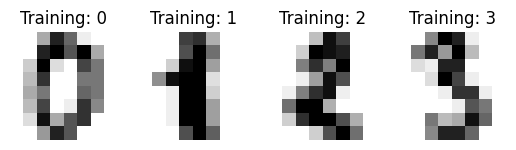

In [84]:
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)

In [126]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [113]:
image0 = digits.images[0]

In [119]:
image0 = image0.reshape(1,-1)

In [124]:
image0[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

digits.data chính là phiên bản đã được flatten của images

In [131]:
data_train = digits.data
X_train, X_test, y_train, y_test = train_test_split(data_train, digits.target, test_size = 0.2, random_state = 36)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1437, 64), (1437,), (360, 64), (360,))

In [133]:
# base model svm
model_svm_images = svm.SVC(kernel = 'linear', C=1)
model_svm_images.fit(X_train, y_train)
y_pred = model_svm_images.predict(X_test)
accuracy_score(y_test, y_pred)

0.9722222222222222

In [134]:
# tuning tham số
params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
'gamma': [0.0001, 0.001, 0.01, 0.1],
'kernel':['linear','rbf', 'poly'] }
classifier_images = GridSearchCV(estimator = svm.SVC(), cv = cv, n_jobs = -1, scoring = 'accuracy', param_grid = params_grid)
classifier_images.fit(X_train, y_train)
print(classifier_images.best_estimator_)

SVC(C=10, gamma=0.001)


In [136]:
final_model_svm_image = svm.SVC(C=10, gamma=0.001)
final_model_svm_image.fit(X_train, y_train)
accuracy_score(y_test,final_model_svm_image.predict(X_test))

0.9944444444444445